# Southern Ocean Band Climatologies

This code will create climatologies / timeseries by Southern Ocean Band

## Importing Packages

In [33]:
import matplotlib.pyplot as plt 
from scipy import stats
import numpy as np
import pandas as pd
import xarray as xr
#import gcsfs # Pythonic file-system for Google Cloud Storage - we do not use right now 
import os.path
import xesmf as xe
from scipy.signal import detrend
import turtle
import dask.array as da

import os
from netCDF4 import MFDataset, Dataset

In [2]:
import warnings
warnings.filterwarnings("ignore") 

## Set up for Regridding Used in Code 

This is just setting up an empty xarray with space for latitude to run -90 degrees south to 90 degrees north, and longitude to run from 0 to 360 degrees going eastward

In [14]:
# Another method for out grid: 
ds_out = xr.Dataset({'lat': (['lat'], np.arange(-90, 90, 1.0)),
                     'lon': (['lon'], np.arange(1, 361, 1.0)),
                    }
                   )
ds_out


<xarray.Dataset> Size: 4kB
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 3kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
Data variables:
    *empty*

## Frontal Zones 

Load Frontal Zone Data 

In [3]:
zones = {
    "siz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/siz_grid.npy'),
    "az": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/az_grid.npy'),
    "saz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/saz_grid.npy'),
    "stz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/stz_grid.npy'),
    "pfz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/pfz_grid.npy')
}

print("Loaded")

for key in zones:
    zones[key] = zones[key].astype(float)
    zones[key] = np.where(zones[key] == 0, np.nan, zones[key])

siz_zone = zones['siz']
az_zone = zones['az']
saz_zone = zones['saz']
stz_zone = zones['stz']
pfz_zone = zones['pfz']

Loaded


In [5]:

zones = {
    "siz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/siz_grid.npy'),
    "az": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/az_grid.npy'),
    "saz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/saz_grid.npy'),
    "stz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/stz_grid.npy'),
    "pfz": np.load('/glade/u/home/lilmi/2026ClimateBigData/FrontalZones/pfz_grid.npy')
}

print("Loaded")

for key in zones:
    zones[key] = zones[key].astype(float)
    zones[key] = np.where(zones[key] == 0, np.nan, zones[key])

siz_zone = zones['siz']
az_zone = zones['az']
saz_zone = zones['saz']
stz_zone = zones['stz']
pfz_zone = zones['pfz']

Loaded


In [6]:
print(siz_zone.shape)
# masked_ds = ds.where(nmask) 
#boolian values -. True (1) or False (0) 
#SIZ ZONE MASK
mask_siz = np.isnan(np.flipud(siz_zone)) #sends nan values to True, non nans to False
#AZ ZONE MASK
mask_az = np.isnan(np.flipud(az_zone)) #sends nan values to True, non nans to False
#SAZ ZONE MASK
mask_saz = np.isnan(np.flipud(saz_zone)) #sends nan values to True, non nans to False
#STZ ZONE MASK
mask_stz = np.isnan(np.flipud(stz_zone)) #sends nan values to True, non nans to False
#PFZ ZONE MASK
mask_pfz = np.isnan(np.flipud(pfz_zone))  #sends nan values to True, non nans to False


zone_masks = {
    "siz": mask_siz,
    "az": mask_az,
    "saz": mask_saz,
    "stz": mask_stz,
    "pfz": mask_pfz
}

print(mask_pfz)

(180, 360)
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


## Dataset Generation - Southern Ocean Bands

Here we will save of data for climatologies (12 point (each month) data averaged over 20 years - 1991 to 2010) and for the full time series (one data point per month for 20 years) for both of the NCAR models - CESM2 and CESM2-WACCM. 

Model paths include variables for:  
- tos - Sea Surface Temperature 
- phyc - Phytoplankton Biomass
- chl - Cholorphyll
- dissic - Dissolved Inorganic Carbon
- fgco2 - CO2 Flux
- mlotst - Mix Layer Depth 
- ph - pH (a measure of acidity) 
- spco2 - pCO2 (partial pressure of CO2)
- sos - Salinity
- talk - Total Alkalinity
- si - Silicate
- no3 - Nitrate 
- co3 - Carbonate

models = ['CESM2', 'CESM2-WACCM', 'GFDL-CM4',
         'GFDL-ESM4', 'IPSL-CM6A-LR', 'GISS-E2-1-G',
         'GISS-E2-1-G-CC', 'MIROC-ES2L', 'NorCPM1',
         'NorESM2-LM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR',
         'UKESM1-0-LL', 'CNRM-ESM2-1', 'ACCESS-ESM1-5',
         'CanESM5-CanOE', 'CanESM5', 'EC-Earth3']

In [11]:
def get_path(model, variable, data_type, experiment_id, activity_id):
   
    import intake
    
    member_id_list = ["r1i1p1f1", "r1i1p1f2", "r1i1p1f2", "r1i1p2f1", "r4i1p1f1","r13i1p1f2"]
    grid_list = ["gr", "gn"] 
    
    url_cimp6 = '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cmip6.json'
    cat = intake.open_esm_datastore(url_cimp6)
    cat.df.head()
    
    selected_run = None
    selected_grid = None
    
    for run in member_id_list:
        cat_subset = cat.search(
            experiment_id=[experiment_id],
            table_id= data_type,
            variable_id= variable,
            source_id=model,
            member_id=run,
            activity_id = activity_id
        )
        
        if not cat_subset.df.empty:  # If we find a valid run, store it
            selected_run = run
            
            # Now try different grid labels
            for grid in grid_list:
                #print(f"Trying grid: {grid}")  
                cat_subset = cat.search(
                    experiment_id=[experiment_id],
                    table_id= data_type,
                    variable_id= variable,
                    source_id= model,
                    member_id=selected_run,
                    activity_id = activity_id,
                    grid_label=grid
                )
    
                if not cat_subset.df.empty:  # If we find a valid grid, store it and stop
                    selected_grid = grid
                    break  # Stop searching for grids
    
            break  # Stop searching for runs once we find a valid one
    
    #print(f"Selected run: {selected_run}, Selected grid: {selected_grid}")
    path = cat_subset.df["path"].tolist()
    return path

In [12]:
path = get_path("CESM2","no3", "Omon", "historical","CMIP")
print(path)

['/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/mlotst/gr/v20190308/mlotst_Omon_CESM2_historical_r1i1p1f1_gr_185001-201412.nc']


## Create Climatologies 

In [ ]:
#climatologies
start_year = '1991'  # start year for data 
end_year = '2010'   # End year for data - this gives a 20 year time period 

models = ['CESM2'] # List of models to create climatologies for 

variables = ['tos','mlotst','sos', 'rsntds']

regions = ['siz', 'az', 'saz', 'stz', 'pfz']

for model in models:  # runs through every model in the models list above
    # model will correspond to one of the models in the list above depeding on which loop iteration
    print(model) # prints model loop is on 
    
    #each model has a unique code that is part of its path (see paths above)  
 
    for var in variables: # for every model in model list we will go through ever variable in variables list
        print(var)
        path = get_path(model,var, "Omon", "historical","CMIP")
        #print(path)

        if not path:  
            print(model, var, "NO DATA")
            continue
        else:
            dataset = xr.open_mfdataset(path, chunks = None)  # opens dataset in xarray (see above) 
            dataset_in = dataset  # renames dataset to "dataset in" 
    
        for region in regions:  # loops over each southern ocean region 
            print(region)

            
            if isinstance(dataset_in, xr.Dataset): # this checks that the dataset sucessfully opened as an xarray 
    
                # this slices the dataset to the start and end year specified above and saves that to new variable ds 
                ds = dataset_in.sel(time=slice(start_year, end_year))[var]
    
                # the next 10 lines check for common names of coordinates in the data system and uniformly renames them 
                # then is selects the surface level for all datasets
                if 'latitude' in ds.coords: 
                     ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})
                if 'nav_lat' in ds.coords:
                     ds = ds.rename({'nav_lon': 'lon', 'nav_lat': 'lat'})
                if 'lev_partial' in ds.coords:
                     ds = ds.isel(lev_partial=0) #selects first value in depth feild (index of 1) 
                if 'olevel' in ds.coords:
                     ds = ds.isel(olevel=0) #selects first value in depth feild (index of 1) 
                if 'lev' in ds.coords:
                     ds = ds.isel(lev=0) #selects first value in depth feild (index of 1) 
                
                #discards any negative data for variable that should not have negative values 
                if var == 'phyc' or var == 'chl'  or var == 'no3' or var == 'si' or var == 'dfe' or var == 'dissic' or var == 'talk':
                    ds = ds.where(ds>=0)


                # Regridding Data Here - puts all model data sets on same grid space
                # this is where we use the blank xarray created above
                ds_in = xr.Dataset({"lat": ds.lat, "lon": ds.lon})  # data going into regridding 
                dsr = xe.Regridder(ds_in, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
                dsr._grid_in = None
                dsr._grid_out = None
                dsr_out0 = dsr(ds)
                dsr_out = xr.Dataset({var:dsr_out0}) # regridded data set is spit out 
                
                # start of calculations for seasonal datasets 
                #print((dsr_out[var]).shape)
                if dsr_out[var].shape[0]==12*20:  #if the dataset has the desired number of months (12 months * number of years in your range) 
                
        #Calculations by region  
    
                    print('calculating')
                    
                    ds_np = (dsr_out).where(zone_masks[region] == False) 
               
                    # this section is detrending the data - do not worry about understanding this
                    dsm_np = ds_np[var].mean(dim='time',skipna=1) #averaging
                    anom_np = ds_np[var] - dsm_np
                    anom_np.load()
                    anom_detrended_np = xr.apply_ufunc(detrend, anom_np.fillna(0).chunk({"lon":45,"lat":45}), kwargs={'axis': 0},dask="parallelized", output_dtypes=[anom_np.dtype]).where(~anom_np.isnull())
                    detrend_np = anom_detrended_np + dsm_np
                    #print(detrend_np)
                    #detrending done 
            
                    # this line averages groups' data by month, then takes the time mean, then the mean over all points in space 
                    #should leave you with a dataset of 12 points
                    do_np = detrend_np.groupby('time.month').mean('time',skipna=1).mean('lon',skipna=1).mean('lat',skipna=1).values
                
                    #print(do_np) # check you are getting 12 point datasets 
                    
                    #saves calculated dataset to the indicated path

            
                    savef_path ='/glade/u/home/lilmi/2026ClimateBigData/CMIP6ModelClimatologies/' + model + '_' + var + start_year + end_year  + '_' + region + '.txt'  
                    
                    with open(savef_path, 'w') as npf:
                        for idata in do_np:
                            npf.write(str(idata) +"\n") # writes data to a string file that can be read later 


CESM2
tos
siz
calculating
az
calculating
saz
calculating
stz
calculating
pfz
calculating
mlotst
siz
calculating
az
calculating
saz
calculating
stz
calculating
pfz
calculating
sos
siz
calculating
az
calculating
saz
calculating
stz
calculating
pfz
calculating
rsntds
siz
calculating
az
calculating
saz
calculating
stz
calculating


## Plotting 

This section will do unit conversions and all the graphics to actuall plot the data files. We are using subplots from matplotlib. 
- This link: (https://matplotlib.org/stable/api/matplotlib_configuration_api.html)  is very helpful when trying to understand how to work with any of the graphics stuff here. 


In [22]:
Time_months = ('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec')
# lables for months 
start_year=1991 #Start time for Data 
end_year=2010 # End time for Data 

#This is an array of color values to give each model a unique color in the plot (we are starting with just one model, add more colors if you use more models 
 
newcolors = ["#48a6cf", "#ad1f9d"]


#colors is the array with the color values that you will call later 
colors=np.array(newcolors)


**Physics Vars Plotting**

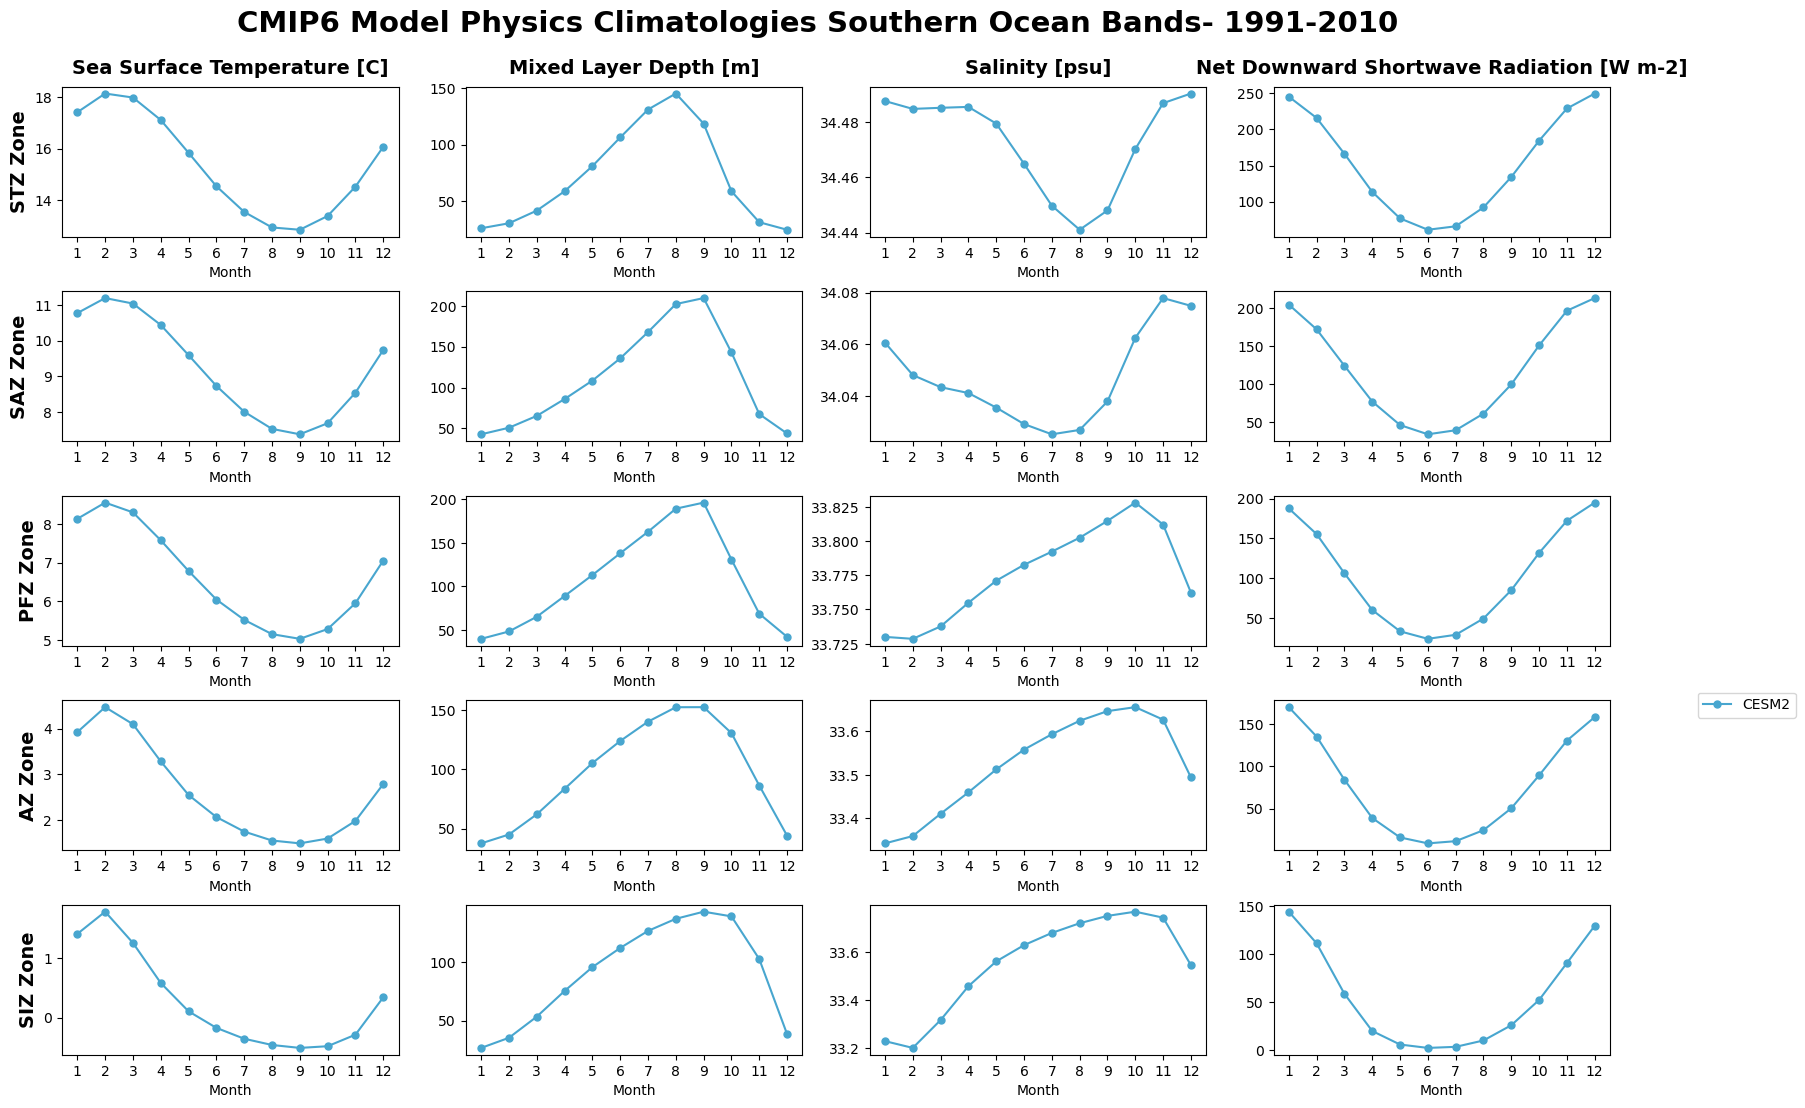

CPU times: user 1.44 s, sys: 47.8 ms, total: 1.49 s
Wall time: 1.49 s


In [23]:
%%time

regions = ['stz','saz','pfz', 'az', 'siz' ]
var_names = ['tos','mlotst','sos', 'rsntds']


models = ['CESM2']

plot_titles = ["Sea Surface Temperature [C]", "Mixed Layer Depth [m]", 
               "Salinity [psu]", 'Net Downward Shortwave Radiation [W m-2]']

zone_titles = {"siz": 'SIZ Zone', "az": 'AZ Zone',
               "saz": 'SAZ Zone',  "stz": 'STZ Zone',  "pfz":'PFZ Zone'}

start_year = '1991'
end_year = '2010'

fig, axes = plt.subplots(nrows=len(regions), ncols=len(var_names), figsize=(18, 11))
fig.subplots_adjust(left=0.030, bottom=0.03, right=0.89, top=0.91, hspace=0.365, wspace=0.2)

for i, region in enumerate(regions):
    for j, var in enumerate(var_names):
        ax = axes[i, j]
        for mi, model in enumerate(models):
            ofn = f'/glade/u/home/lilmi/Carbon Project/CMIP6ModelClimatologies/{model}_{var}{start_year}{end_year}_{region}.txt'
            #print(ofn)
            if os.path.exists(ofn):
                dm = []
                with open(ofn, "r") as rf:
                    dm = [float(line.strip()) for line in rf]
                
                s = np.array(dm)
                xmon = np.arange(1, 13)
                
                if var == 'chl':
                    s = s * 1e6
                elif var in ['phyc', 'phycos', "phydiat", "phypico", "phydiaz"]:
                    s = s * 12 * 1000
                elif var in ['no3', 'si', 'o2']:
                    s = s * 1e3
                elif var == 'spco2':
                    s = (s * 1000) / 101.325 # converstion from Pa to uatm 
                
                ax.plot(xmon, s, label=model, marker='o', markersize=5, color=colors[mi])
            else:
                print('Did not find', model, var)
                ax.plot([], [], label=model, marker='o', markersize=7, linewidth=2.0, color=colors[mi])

        if j == 0:
            ax.set_ylabel(zone_titles[region], fontsize=14, fontweight='bold')
        if i == 0:
            ax.set_title(plot_titles[j], fontsize=14, fontweight='bold', y=1.03)
        #ax.set_title(plot_titles[j], fontsize=12, y=1.03)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 1000))
        ax.set_xticks(np.arange(1, 13))
        ax.set_xlabel("Month")
        
fig.legend(models, loc='lower right', bbox_to_anchor=(0.997, 0.33))
plt.suptitle(f'CMIP6 Model Physics Climatologies Southern Ocean Bands- {start_year}-{end_year}', fontsize=21, weight='bold', x=0.45)
plt.show()


**Carbon Var Plotting**

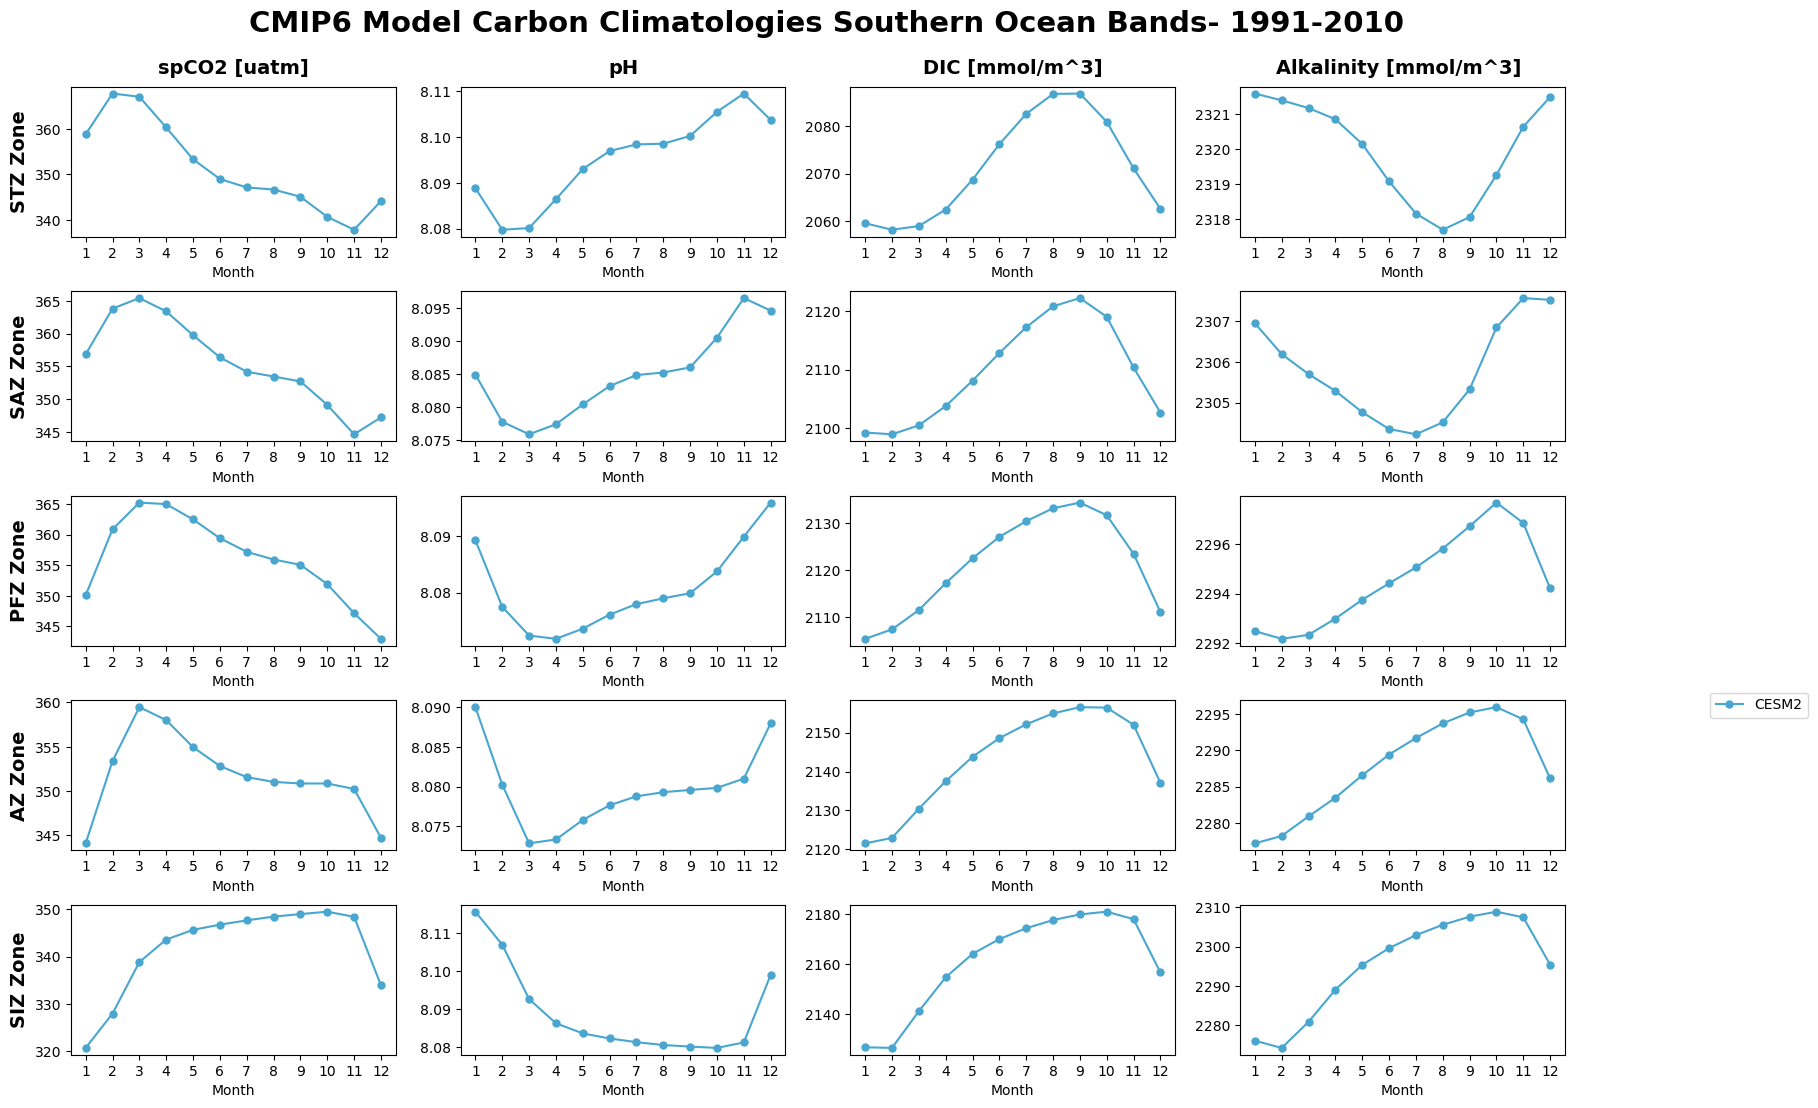

CPU times: user 1.09 s, sys: 23.9 ms, total: 1.11 s
Wall time: 1.13 s


In [31]:
%%time

regions = ['stz','saz','pfz', 'az', 'siz' ]

var_names = ["spco2", "ph", "dissic", "talk"]

models = ['CESM2']


plot_titles = ["spCO2 [uatm]", "pH", 
               "DIC [mmol/m^3]", "Alkalinity [mmol/m^3] "]

zone_titles = {"siz": 'SIZ Zone', "az": 'AZ Zone',
               "saz": 'SAZ Zone',  "stz": 'STZ Zone',  "pfz":'PFZ Zone'}

start_year = '1991'
end_year = '2010'

fig, axes = plt.subplots(nrows=len(regions), ncols=len(var_names), figsize=(18, 11))
fig.subplots_adjust(left=0.030, bottom=0.03, right=0.86, top=0.91, hspace=0.365, wspace=0.2)

for i, region in enumerate(regions):
    for j, var in enumerate(var_names):
        ax = axes[i, j]
        for mi, model in enumerate(models):
            ofn = f'/glade/u/home/lilmi/2026ClimateBigData/CMIP6ModelClimatologies/{model}_{var}{start_year}{end_year}_{region}.txt'
            #print(ofn)
            if os.path.exists(ofn):
                dm = []
                with open(ofn, "r") as rf:
                    dm = [float(line.strip()) for line in rf]
                
                s = np.array(dm)
                xmon = np.arange(1, 13)
                
                if var == 'chl':
                    s = s * 1e6
                elif var in ['phyc', 'phycos', "phydiat", "phypico", "phydiaz"]:
                    s = s * 12 * 1000
                    
                elif var in ['no3', 'si', 'o2', 'co3', 'dissic','talk']:
                    s = s * 1e3
                elif var in ['dfe']:
                    s = s * 1e6
                elif var == 'spco2':
                    s = (s * 1000) / 101.325
                
                ax.plot(xmon, s, label=model, marker='o', markersize=5, color=colors[mi])
            else:
                print('Did not find', model, var)
                ax.plot([], [], label=model, marker='o', markersize=7, linewidth=2.0, color=colors[mi])

        if j == 0:
            ax.set_ylabel(zone_titles[region], fontsize=14, fontweight='bold')
        if i == 0:
            ax.set_title(plot_titles[j], fontsize=14, fontweight='bold', y=1.03)
        #ax.set_title(plot_titles[j], fontsize=12, y=1.03)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 1000))
        ax.set_xticks(np.arange(1, 13))
        ax.set_xlabel("Month")
        
fig.legend(models, loc='lower right', bbox_to_anchor=(0.999, 0.33))
plt.suptitle(f'CMIP6 Model Carbon Climatologies Southern Ocean Bands- {start_year}-{end_year}', fontsize=21, weight='bold', x=0.45)
plt.show()


**Nutrient Var Plotting**

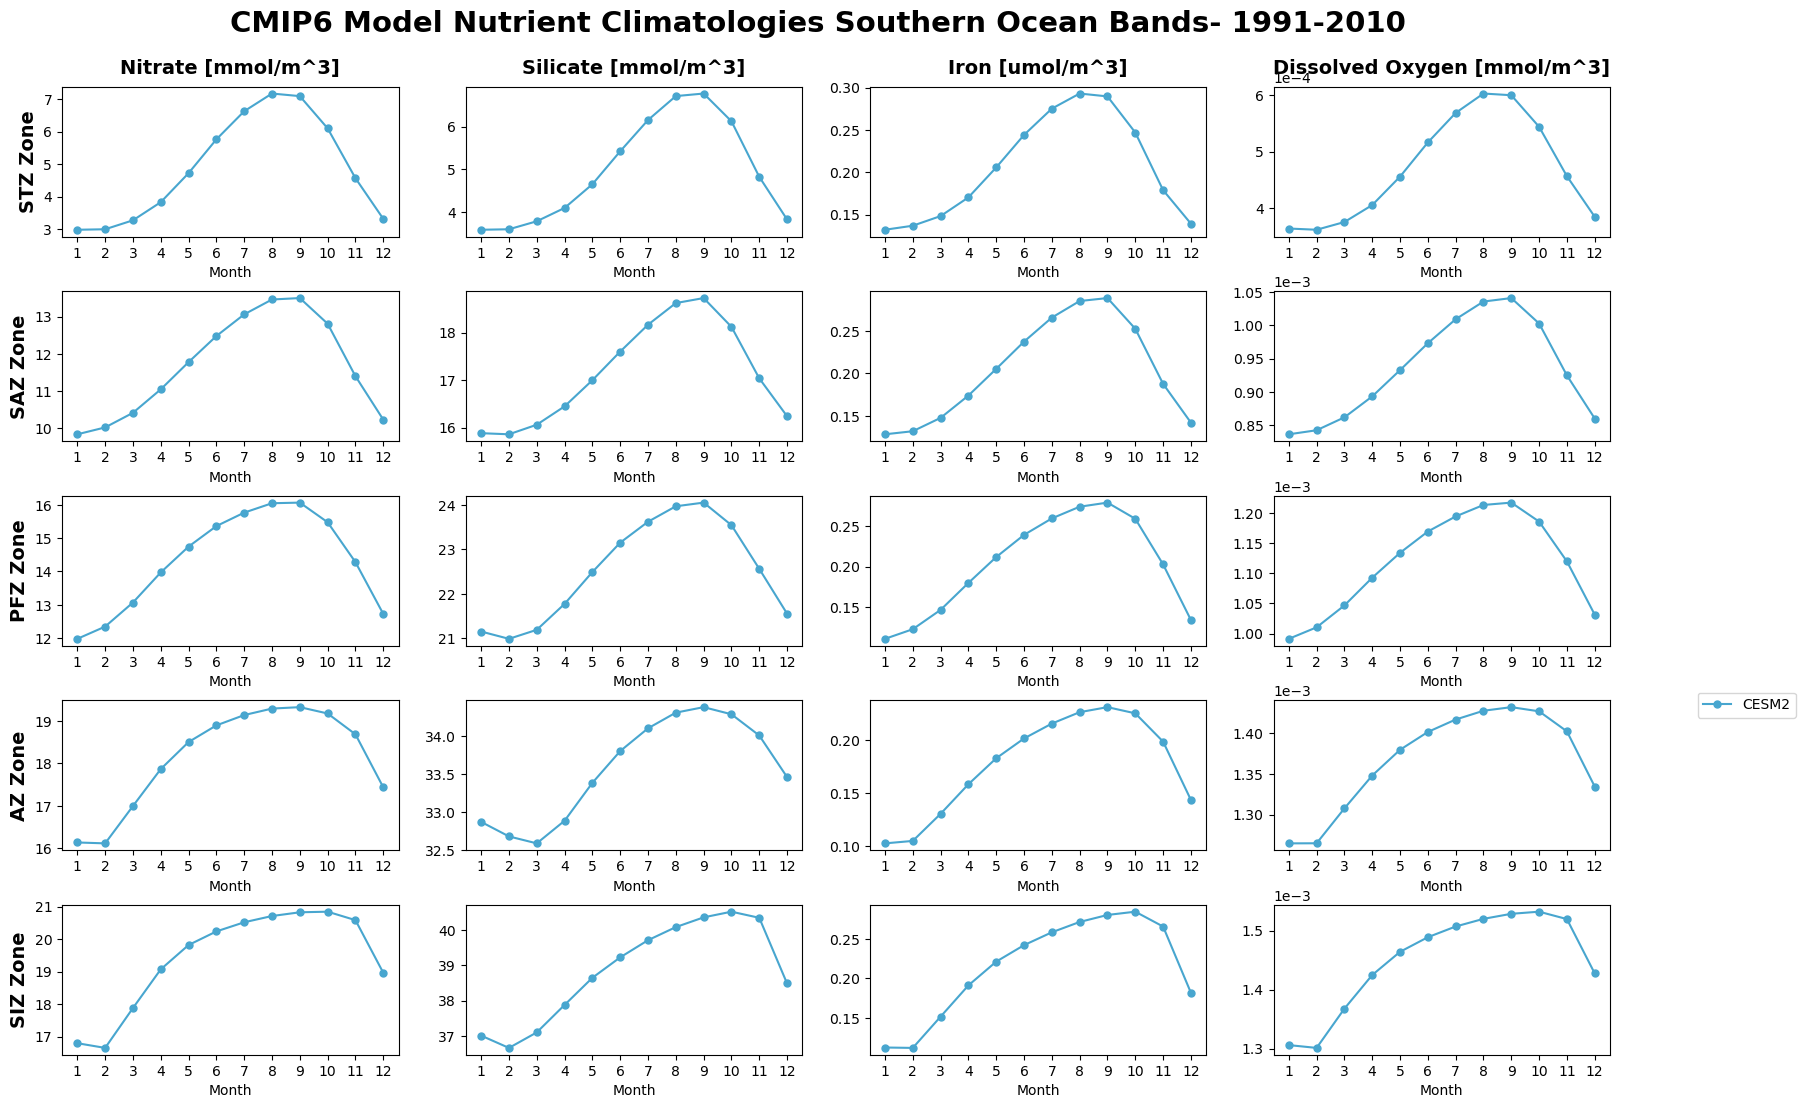

CPU times: user 1.39 s, sys: 67.8 ms, total: 1.46 s
Wall time: 1.46 s


In [30]:
%%time

regions = ['stz','saz','pfz', 'az', 'siz' ]

var_names = ["no3", "si", "dfe", "po4"]

models = ['CESM2']


plot_titles = ["Nitrate [mmol/m^3]", "Silicate [mmol/m^3]", 
               "Iron [umol/m^3]", "Dissolved Oxygen [mmol/m^3]"]

zone_titles = {"siz": 'SIZ Zone', "az": 'AZ Zone',
               "saz": 'SAZ Zone',  "stz": 'STZ Zone',  "pfz":'PFZ Zone'}

start_year = '1991'
end_year = '2010'

fig, axes = plt.subplots(nrows=len(regions), ncols=len(var_names), figsize=(18, 11))
fig.subplots_adjust(left=0.030, bottom=0.03, right=0.89, top=0.91, hspace=0.365, wspace=0.2)

for i, region in enumerate(regions):
    for j, var in enumerate(var_names):
        ax = axes[i, j]
        for mi, model in enumerate(models):
            ofn = f'/glade/u/home/lilmi/2026ClimateBigData/CMIP6ModelClimatologies/{model}_{var}{start_year}{end_year}_{region}.txt'
            #print(ofn)
            if os.path.exists(ofn):
                dm = []
                with open(ofn, "r") as rf:
                    dm = [float(line.strip()) for line in rf]
                
                s = np.array(dm)
                xmon = np.arange(1, 13)
                
                if var == 'chl':
                    s = s * 1e6
                elif var in ['phyc', 'phycos', "phydiat", "phypico", "phydiaz"]:
                    s = s * 12 * 1000
                    
                elif var in ['no3', 'si', 'o2', 'po4']:
                    s = s * 1e3
                elif var in ['dfe']:
                    s = s * 1e6
                elif var == 'spco2':
                    s = (s * 1000) / 101.325
                
                ax.plot(xmon, s, label=model, marker='o', markersize=5, color=colors[mi])
            else:
                print('Did not find', model, var)
                ax.plot([], [], label=model, marker='o', markersize=7, linewidth=2.0, color=colors[mi])

        if j == 0:
            ax.set_ylabel(zone_titles[region], fontsize=14, fontweight='bold')
        if i == 0:
            ax.set_title(plot_titles[j], fontsize=14, fontweight='bold', y=1.03)
        #ax.set_title(plot_titles[j], fontsize=12, y=1.03)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 1000))
        ax.set_xticks(np.arange(1, 13))
        ax.set_xlabel("Month")
        
fig.legend(models, loc='lower right', bbox_to_anchor=(0.997, 0.33))
plt.suptitle(f'CMIP6 Model Nutrient Climatologies Southern Ocean Bands- {start_year}-{end_year}', fontsize=21, weight='bold', x=0.45)
plt.show()


**Biology**

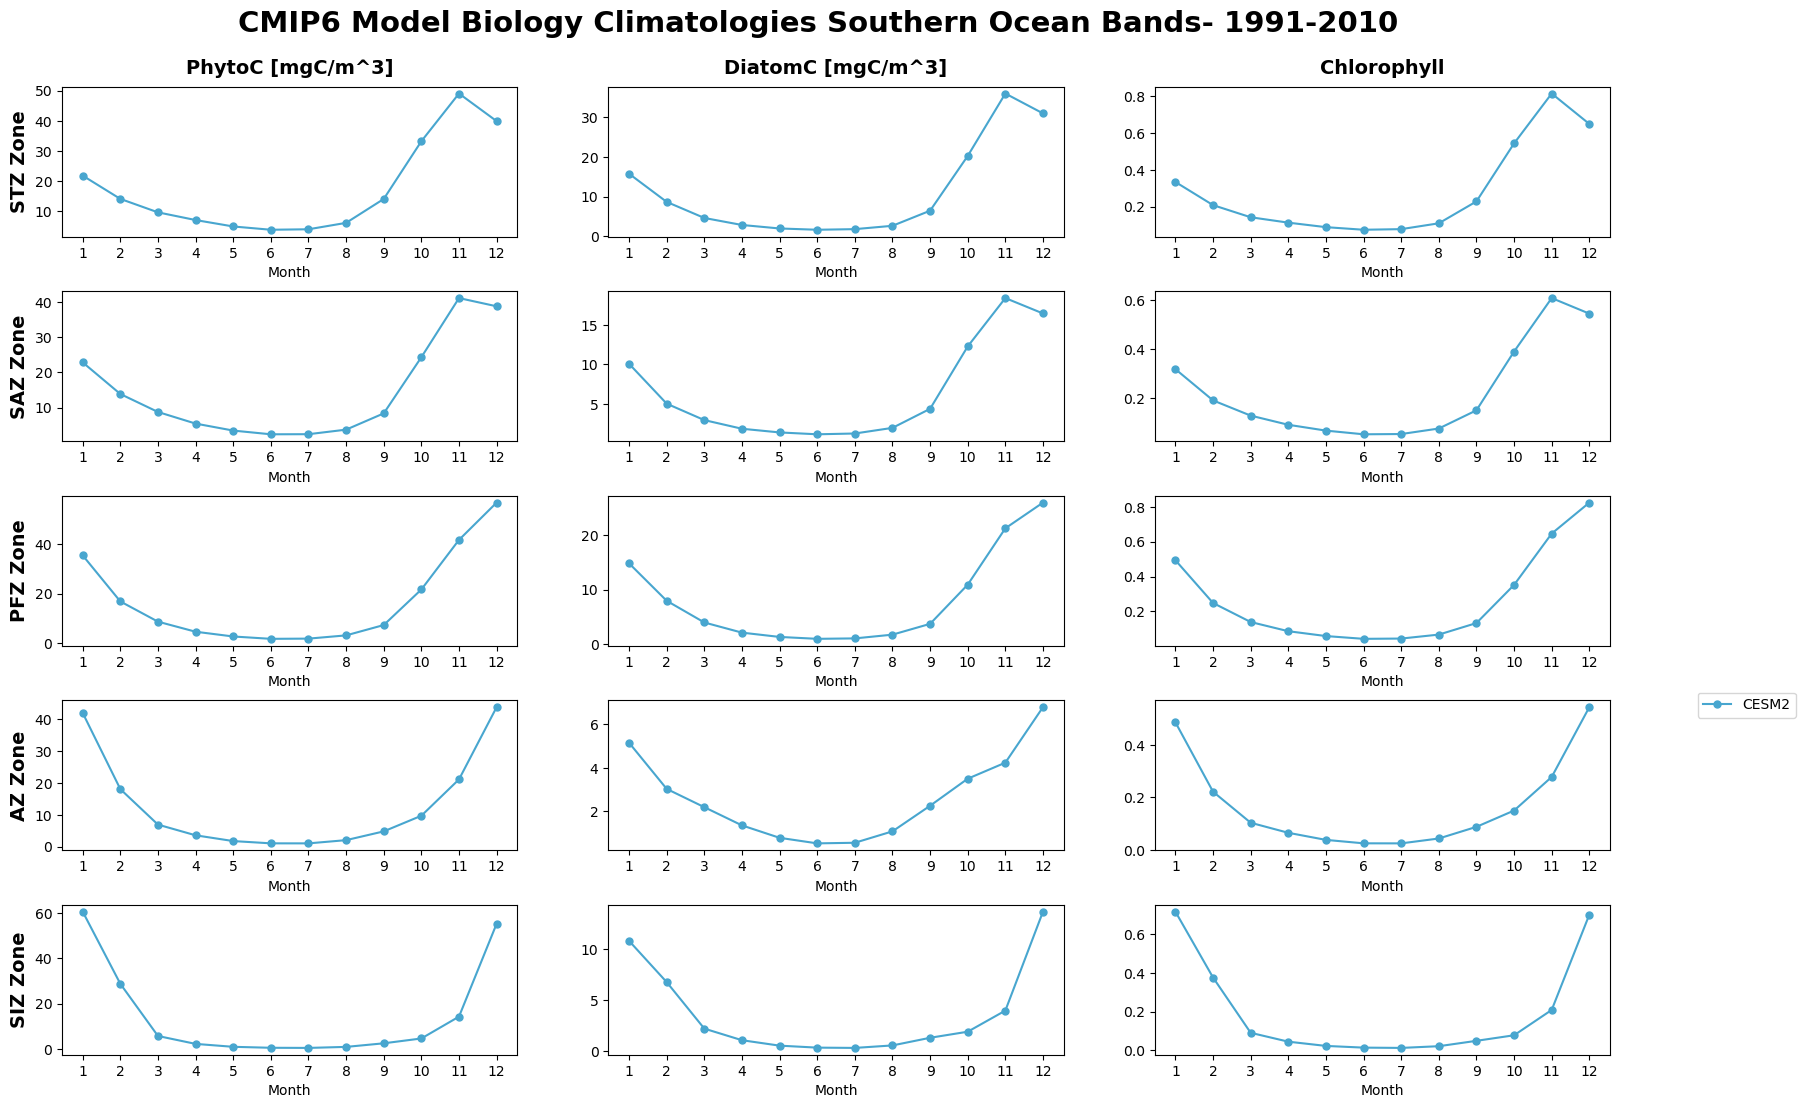

CPU times: user 1.33 s, sys: 51.2 ms, total: 1.38 s
Wall time: 1.41 s


In [27]:
%%time

regions = ['stz','saz','pfz', 'az', 'siz' ]

var_names = ["phyc", "phydiat","chl"]

models = ['CESM2']

plot_titles = ["PhytoC [mgC/m^3]", "DiatomC [mgC/m^3]", 
               "Chlorophyll"]

zone_titles = {"siz": 'SIZ Zone', "az": 'AZ Zone',
               "saz": 'SAZ Zone',  "stz": 'STZ Zone',  "pfz":'PFZ Zone'}

start_year = '1991'
end_year = '2010'

fig, axes = plt.subplots(nrows=len(regions), ncols=len(var_names), figsize=(18, 11))
fig.subplots_adjust(left=0.030, bottom=0.03, right=0.89, top=0.91, hspace=0.365, wspace=0.2)

for i, region in enumerate(regions):
    for j, var in enumerate(var_names):
        ax = axes[i, j]
        for mi, model in enumerate(models):
            ofn = f'/glade/u/home/lilmi/Carbon Project/CMIP6ModelClimatologies/{model}_{var}{start_year}{end_year}_{region}.txt'
            #print(ofn)
            if os.path.exists(ofn):
                dm = []
                with open(ofn, "r") as rf:
                    dm = [float(line.strip()) for line in rf]
                
                s = np.array(dm)
                xmon = np.arange(1, 13)
                
                if var == 'chl':
                    s = s * 1e6
                elif var in ['phyc', 'phycos', "phydiat", "phypico", "phydiaz"]:
                    s = s * 12 * 1000
                elif var in ['no3', 'si', 'o2']:
                    s = s * 1e3
                elif var == 'spco2':
                    s = (s * 1000) / 101.325
                
                ax.plot(xmon, s, label=model, marker='o', markersize=5, color=colors[mi])
            else:
                print('Did not find', model, var)
                ax.plot([], [], label=model, marker='o', markersize=7, linewidth=2.0, color=colors[mi])

        if j == 0:
            ax.set_ylabel(zone_titles[region], fontsize=14, fontweight='bold')
        if i == 0:
            ax.set_title(plot_titles[j], fontsize=14, fontweight='bold', y=1.03)
        #ax.set_title(plot_titles[j], fontsize=12, y=1.03)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 1000))
        ax.set_xticks(np.arange(1, 13))
        ax.set_xlabel("Month")
        
fig.legend(models, loc='lower right', bbox_to_anchor=(0.997, 0.33))
plt.suptitle(f'CMIP6 Model Biology Climatologies Southern Ocean Bands- {start_year}-{end_year}', fontsize=21, weight='bold', x=0.45)
plt.show()
